# testing_adaptive_2.ipynb

Structured notebook for simulation and Lyapunov diagnostics:

- Integration (RK45 / DOP853 / RK4 / symplectic)
- Phase portrait (2D or 3D)
- Lyapunov exponents vs time
- Multi-config plateau test (2 and 3 decimals) with Numba backend
- Tolerance sweep

Designed to be driven by StaticParamsConfig exports from the Streamlit app.



In [7]:
# --- Imports + project root wiring ---
import json
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

PROJECT_ROOT = None
for candidate in [Path.cwd()] + list(Path.cwd().parents):
    if (candidate / "core").is_dir() and (candidate / "plotting").is_dir():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate repo root (missing core/ and plotting/)")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from core.solver import integrate_system, integrate_system_rk4
from core.symplectic_solver import (
    integrate_system_symplectic_verlet,
    integrate_system_symplectic_fr,
)
from core.lyapunov import (
    compute_lyapunov_spectrum,
    _integrate_chunk_ivp,
    _integrate_chunk_rk4,
    _rk4_cost_estimate,
    _pack_augmented,
    _unpack_augmented,
    _qr_accumulate,
    finite_difference_jacobian,
)
from core import numba_backend
from core.lorenz_system_rhs import lorenz_rhs
from core.rossler_system_rhs import rossler_rhs
from core.henon_heiles_system_rhs import (
    henon_heiles_rhs,
    henon_heiles_dq_dt,
    henon_heiles_dp_dt,
)
from core.jacobians_fixed_systems import lorenz_jac, rossler_jac, henon_heiles_jac
from plotting.plotting import phase_portrait

print("OK: imports loaded.")



OK: imports loaded.


## 1) Load config (StaticParamsConfig.json)

If you exported a config from the app, place it next to this notebook
(or change the path below).


In [8]:
# --- Load StaticParamsConfig.json (fallback to a default example if missing) ---
assert PROJECT_ROOT is not None

CONFIG_CANDIDATES = [
    Path("StaticParamsConfig.json"),
    Path("StaticParamsConfig(5).json"),
    PROJECT_ROOT / "tests" / "StaticParamsConfig.json",
    PROJECT_ROOT / "tests" / "StaticParamsConfig(5).json",
    PROJECT_ROOT / "tests" / "StaticParamsConfig_5.json",
    PROJECT_ROOT / "examples" / "StaticParamsConfig.json",
]


def load_config(path: Path) -> dict:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


cfg = None
for path in CONFIG_CANDIDATES:
    if path.exists():
        cfg = load_config(path)
        print(f"Loaded config: {path.resolve()}")
        break

if cfg is None:
    cfg = {
        "schema_version": "1.0",
        "system": {
            "system_key": "lorenz",
            "var_names": ["x", "y", "z"],
            "eq_lines": [],
            "params": {"sigma": 10.0, "rho": 28.0, "beta": 8.0 / 3.0},
        },
        "integration": {
            "t0": 0.0,
            "tf": 50.0,
            "dt": 0.01,
            "y0": [1.0, 1.0, 1.0],
            "solver_kind": "rk45",
            "solve_options": {"rtol": 1e-6, "atol": 1e-8},
        },
        "postprocess": {"transient_steps": 0},
        "plots": {
            "plot_mode": "2D phase plane",
            "phase_axes": {"x_idx": 0, "y_idx": 1, "z_idx": None},
        },
        "lyapunov": {
            "enabled": True,
            "settings": {
                "t_transient": 0.0,
                "t_measure": 10.0,
                "qr_every_steps": 10,
                "qr_interval": 0.1,
                "jacobian": "analytic",
                "fd_eps": 1e-8,
            },
        },
    }
    print("Loaded fallback config (Lorenz).")

cfg


Loaded config: /home/odygoundi/Documents/nds-simulator/tests/StaticParamsConfig.json


{'schema_version': '1.0',
 'app': {'name': 'nlds-simulator',
  'commit': '89f1a4d7aa6a3c8fe73d28aa44321a25d6e2078f'},
 'timestamp_utc': '2026-01-21T01:15:16Z',
 'system': {'system_key': 'custom',
  'var_names': ['x1', 'x2', 'x3'],
  'eq_lines': ['alpha * x2 + x1 * x3',
   '- beta * x1 + x2 * x3',
   '1 - x1**2 - x2**2'],
  'params': {'alpha': 0.05, 'beta': 1.0},
  'params_text': 'alpha = 0.05\nbeta = 1',
  'auto_jacobian': True,
  'use_jacobian': True},
 'integration': {'t0': 0.0,
  'tf': 20000.0,
  'dt': 0.01,
  'y0': [-1.0, -1.0, 4.0],
  'solver_kind': 'ivp',
  'solve_options': {'rtol': 1e-06, 'atol': 1e-08}},
 'postprocess': {'transient_steps': 5000},
 'plots': {'plot_mode': '2D phase plane',
  'phase_axes': {'x_idx': 0, 'y_idx': 1, 'z_idx': None}},
 'lyapunov': {'enabled': True,
  'settings': {'dt': 0.01,
   't_transient': 19999.0,
   't_measure': 1.0,
   'qr_every_steps': 10,
   'qr_interval': 0.1,
   'keep_last_steps': 100,
   'jacobian': 'analytic',
   'fd_eps': 1e-08}}}

## 2) Build RHS / Jacobian

Supported `system_key`:
- `lorenz`
- `rossler`
- `henon_heiles`
- `custom` (SymPy expressions in `eq_lines`)


In [9]:
SAFE_FUNCS = {
    "sin": sp.sin, "cos": sp.cos, "tan": sp.tan,
    "exp": sp.exp, "log": sp.log, "sqrt": sp.sqrt,
    "sinh": sp.sinh, "cosh": sp.cosh, "tanh": sp.tanh,
    "abs": sp.Abs,
}


def parse_params_text(text: str) -> dict:
    params = {}
    for line in (text or "").splitlines():
        line = line.strip()
        if not line:
            continue
        if "=" not in line:
            raise ValueError(f"Parameter line must be name=value. Got: {line!r}")
        name, val = line.split("=", 1)
        name = name.strip()
        val = val.strip()
        if name.lower() == "t":
            raise ValueError("Parameter name 't' is reserved.")
        params[name] = float(val)
    return params


def build_custom_rhs(var_names, eq_lines, params):
    n = len(var_names)
    if len(eq_lines) != n:
        raise ValueError(f"Need exactly {n} equations. Got {len(eq_lines)}.")

    t_sym = sp.Symbol("t")
    var_syms = sp.symbols(var_names)
    param_syms = {k: sp.Symbol(k) for k in params.keys()}

    locals_dict = {
        **SAFE_FUNCS,
        "t": t_sym,
        **{name: sym for name, sym in zip(var_names, var_syms)},
        **param_syms,
    }

    exprs = []
    for i, line in enumerate(eq_lines):
        s = (line or "").strip()
        if not s:
            raise ValueError(f"Equation {i+1} is empty.")
        exprs.append(sp.sympify(s, locals=locals_dict))

    args = [t_sym] + list(var_syms) + [param_syms[k] for k in params.keys()]
    f_rhs = sp.lambdify(args, exprs, modules=["numpy"])
    param_values = [float(params[k]) for k in params.keys()]

    def rhs(t, y):
        vals = [float(t)] + list(y) + param_values
        return np.asarray(f_rhs(*vals), dtype=float)

    return rhs


def build_custom_rhs_and_jacobian(var_names, eq_lines, params):
    n = len(var_names)
    if len(eq_lines) != n:
        raise ValueError(f"Need exactly {n} equations. Got {len(eq_lines)}.")

    t_sym = sp.Symbol("t")
    var_syms = sp.symbols(var_names)
    param_syms = {k: sp.Symbol(k) for k in params.keys()}

    locals_dict = {
        **SAFE_FUNCS,
        "t": t_sym,
        **{name: sym for name, sym in zip(var_names, var_syms)},
        **param_syms,
    }

    exprs = []
    for i, line in enumerate(eq_lines):
        s = (line or "").strip()
        if not s:
            raise ValueError(f"Equation {i+1} is empty.")
        exprs.append(sp.sympify(s, locals=locals_dict))

    J = sp.Matrix(exprs).jacobian(var_syms)

    args = [t_sym] + list(var_syms) + [param_syms[k] for k in params.keys()]
    f_rhs = sp.lambdify(args, exprs, modules=["numpy"])
    f_jac = sp.lambdify(args, J, modules=["numpy"])
    param_values = [float(params[k]) for k in params.keys()]

    def rhs(t, y):
        vals = [float(t)] + list(y) + param_values
        return np.asarray(f_rhs(*vals), dtype=float)

    def jac(t, y):
        vals = [float(t)] + list(y) + param_values
        return np.asarray(f_jac(*vals), dtype=float)

    return rhs, jac


def build_custom_symplectic_functions(var_names, eq_lines, params):
    n = len(var_names)
    if n % 2 != 0:
        raise ValueError("Symplectic solvers require an even number of variables.")
    if len(eq_lines) != n:
        raise ValueError(f"Need exactly {n} equations. Got {len(eq_lines)}.")

    n_q = n // 2
    t_sym = sp.Symbol("t")
    var_syms = sp.symbols(var_names)
    q_syms = var_syms[:n_q]
    p_syms = var_syms[n_q:]
    param_syms = {k: sp.Symbol(k) for k in params.keys()}

    locals_dict = {
        **SAFE_FUNCS,
        "t": t_sym,
        **{name: sym for name, sym in zip(var_names, var_syms)},
        **param_syms,
    }

    exprs = []
    for i, line in enumerate(eq_lines):
        s = (line or "").strip()
        if not s:
            raise ValueError(f"Equation {i+1} is empty.")
        exprs.append(sp.sympify(s, locals=locals_dict))

    dq_exprs = exprs[:n_q]
    dp_exprs = exprs[n_q:]

    dq_args = [t_sym] + list(p_syms) + [param_syms[k] for k in params.keys()]
    dp_args = [t_sym] + list(q_syms) + [param_syms[k] for k in params.keys()]
    f_dq = sp.lambdify(dq_args, dq_exprs, modules=["numpy"])
    f_dp = sp.lambdify(dp_args, dp_exprs, modules=["numpy"])
    param_values = [float(params[k]) for k in params.keys()]

    def dq_dt(t, p):
        vals = [float(t)] + list(p) + param_values
        return np.asarray(f_dq(*vals), dtype=float)

    def dp_dt(t, q):
        vals = [float(t)] + list(q) + param_values
        return np.asarray(f_dp(*vals), dtype=float)

    return dq_dt, dp_dt


sys_cfg = cfg.get("system", {})
system_key = str(sys_cfg.get("system_key", "lorenz")).lower().strip()
var_names = list(sys_cfg.get("var_names") or [])
eq_lines = list(sys_cfg.get("eq_lines") or [])
params = dict(sys_cfg.get("params") or {})
if not params and sys_cfg.get("params_text"):
    params = parse_params_text(sys_cfg.get("params_text"))

rhs = None
jac = None
dq_dt = None
dp_dt = None

if system_key == "lorenz":
    rhs = lambda t, y: lorenz_rhs(t, y, **params)
    jac = lambda t, y: lorenz_jac(t, y, **params)
    if not var_names:
        var_names = ["x", "y", "z"]
elif system_key == "rossler":
    rhs = lambda t, y: rossler_rhs(t, y, **params)
    jac = lambda t, y: rossler_jac(t, y, **params)
    if not var_names:
        var_names = ["x", "y", "z"]
elif system_key == "henon_heiles":
    lam = float(params.get("lambda", params.get("lam", 1.0)))
    rhs = lambda t, y: henon_heiles_rhs(t, y, lam=lam)
    jac = lambda t, y: henon_heiles_jac(t, y, lam=lam)
    dq_dt = lambda t, p: henon_heiles_dq_dt(t, p, lam=lam)
    dp_dt = lambda t, q: henon_heiles_dp_dt(t, q, lam=lam)
    if not var_names:
        var_names = ["q1", "q2", "p1", "p2"]
elif system_key == "custom":
    auto_jac = bool(sys_cfg.get("auto_jacobian", False))
    use_jac = bool(sys_cfg.get("use_jacobian", False))
    if auto_jac and use_jac:
        rhs, jac = build_custom_rhs_and_jacobian(var_names, eq_lines, params)
    else:
        rhs = build_custom_rhs(var_names, eq_lines, params)
        jac = None
else:
    raise ValueError(f"Unknown system_key: {system_key}")


## 3) Integrate the system


In [10]:
integ = cfg.get("integration", {})
t0 = float(integ.get("t0", 0.0))
tf = float(integ.get("tf", 50.0))
dt = float(integ.get("dt", 0.01))
y0 = np.asarray(integ.get("y0", [1.0] * max(1, len(var_names))), dtype=float)

solver_kind = str(integ.get("solver_kind", "rk45")).lower().strip()
solve_opts = dict(integ.get("solve_options") or {})

if solver_kind == "ivp":
    solver_kind = "rk45"

if solver_kind not in ("rk45", "dop853", "rk4", "symplectic_verlet", "symplectic_fr"):
    print(f"Unknown solver_kind {solver_kind!r}; using RK45.")
    solver_kind = "rk45"

if solver_kind == "rk45" and "method" not in solve_opts:
    solve_opts["method"] = "RK45"
elif solver_kind == "dop853" and "method" not in solve_opts:
    solve_opts["method"] = "DOP853"

if solver_kind == "rk4":
    sol = integrate_system_rk4(rhs, t_span=(t0, tf), y0=y0, t_step=dt)
elif solver_kind in ("rk45", "dop853"):
    sol = integrate_system(rhs, t_span=(t0, tf), y0=y0, t_step=dt, **solve_opts)
elif solver_kind in ("symplectic_verlet", "symplectic_fr"):
    if dq_dt is None or dp_dt is None:
        if system_key == "custom":
            dq_dt, dp_dt = build_custom_symplectic_functions(var_names, eq_lines, params)
        else:
            raise ValueError("Symplectic solver selected but dq_dt/dp_dt are not available.")
    if solver_kind == "symplectic_verlet":
        sol = integrate_system_symplectic_verlet(
            rhs,
            t_span=(t0, tf),
            y0=y0,
            t_step=dt,
            dq_dt=dq_dt,
            dp_dt=dp_dt,
        )
    else:
        sol = integrate_system_symplectic_fr(
            rhs,
            t_span=(t0, tf),
            y0=y0,
            t_step=dt,
            dq_dt=dq_dt,
            dp_dt=dp_dt,
        )
else:
    sol = integrate_system(rhs, t_span=(t0, tf), y0=y0, t_step=dt, **solve_opts)

if not sol.success:
    raise RuntimeError(f"Integration failed: {sol.message}")

t = np.asarray(sol.t, dtype=float)
Y = np.asarray(sol.y, dtype=float)
print(f"Integrated: t in [{t[0]:.3f}, {t[-1]:.3f}] with {t.size} steps")


Integrated: t in [0.000, 20000.000] with 2000001 steps


## 4) Phase portrait (2D/3D)

We use `phase_portrait` for 2D. If the plot mode is 3D, we render a 3D trajectory.


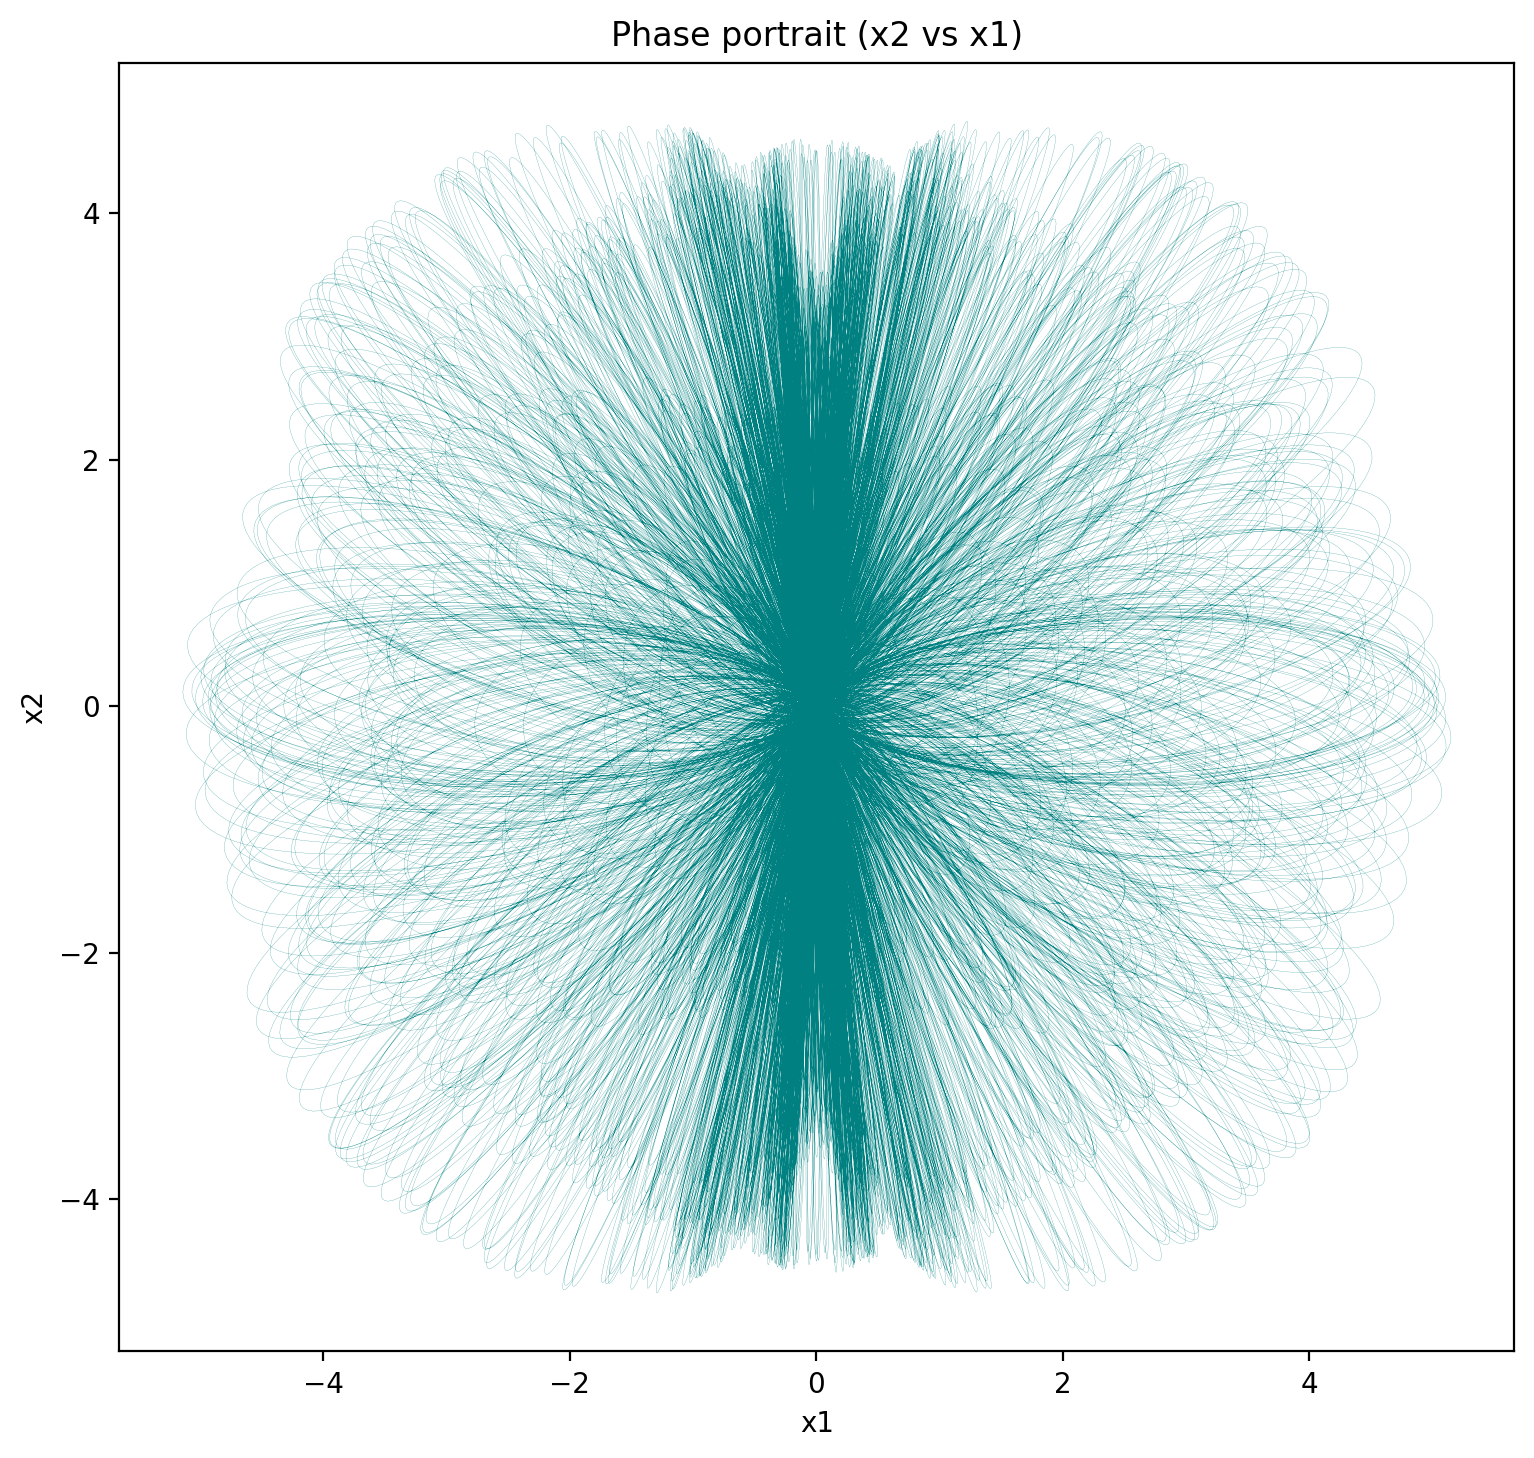

In [11]:
post = cfg.get("postprocess") or {}
transient_steps = int(post.get("transient_steps", 0))
transient_steps = max(0, min(transient_steps, Y.shape[1] - 1))

plots_cfg = cfg.get("plots") or {}
axes_cfg = plots_cfg.get("phase_axes") or {"x_idx": 0, "y_idx": 1, "z_idx": None}
xi = int(axes_cfg.get("x_idx", 0))
yi = int(axes_cfg.get("y_idx", 1))
zi = axes_cfg.get("z_idx", None)
plot_mode = str(plots_cfg.get("plot_mode", "2D phase plane"))

Y_plot = Y[:, transient_steps:]

if "3d" in plot_mode.lower() and Y.shape[0] >= 3:
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

    fig = plt.figure(figsize=(7.0, 5.0))
    ax = fig.add_subplot(111, projection="3d")
    z_index = int(zi) if zi is not None else 2
    ax.plot(
        Y_plot[xi, :],
        Y_plot[yi, :],
        Y_plot[z_index, :],
        linewidth=0.6,
    )
    ax.set_xlabel(var_names[xi])
    ax.set_ylabel(var_names[yi])
    ax.set_zlabel(var_names[z_index])
    ax.set_title("Phase portrait (3D)")
    plt.show()
else:
    phase_portrait(
        Y,
        x_index=xi,
        y_index=yi,
        transient_steps=transient_steps,
        xlabel=var_names[xi],
        ylabel=var_names[yi],
        title=f"Phase portrait ({var_names[yi]} vs {var_names[xi]})",
    )


## 5) Lyapunov exponents vs time

This computes a time series of Lyapunov estimates using QR re-orthonormalization.


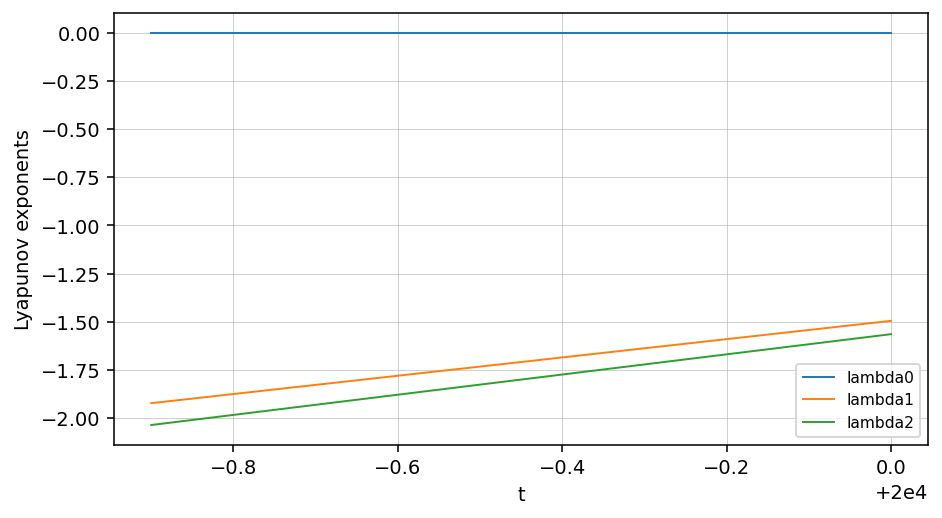

Lyapunov exponents (last): [-6.79130996e-09 -1.49581423e+00 -1.56514822e+00]


In [12]:
def resolve_lyapunov_window(settings, t0, tf, dt):
    total_time = float(tf) - float(t0)
    if total_time <= 0:
        raise ValueError("tf must be > t0 for Lyapunov measurement.")

    keep_last_steps = settings.get("keep_last_steps", None)
    if keep_last_steps is not None:
        keep_steps = int(keep_last_steps)
        if keep_steps <= 0:
            raise ValueError("Lyapunov keep_last_steps must be > 0.")
        t_measure = min(total_time, float(keep_steps) * float(dt))
        t_transient = max(0.0, total_time - t_measure)
        return float(t_transient), float(t_measure)

    t_transient = settings.get("t_transient", None)
    t_measure = settings.get("t_measure", None)
    if t_transient is None or t_measure is None:
        transient_steps = settings.get("transient_steps", None)
        transient_fraction = settings.get("transient_fraction", None)
        if transient_steps is not None:
            t_transient = float(transient_steps) * float(dt)
        elif transient_fraction is not None:
            t_transient = float(transient_fraction) * total_time
        else:
            t_transient = 0.0
        t_measure = total_time - float(t_transient)

    t_transient = float(t_transient)
    t_measure = float(t_measure)
    if t_measure <= 0:
        raise ValueError("No measurement time available for Lyapunov.")
    return t_transient, t_measure


def compute_lyapunov_time_series(
    rhs,
    x0,
    t0,
    dt,
    t_transient,
    t_measure,
    qr_every_steps,
    solve_options=None,
    jac=None,
    fd_eps=1e-8,
    solver_kind="ivp",
    auto_switch_rk4=False,
    rk4_cost_ratio=1.0,
):
    if dt <= 0.0:
        raise ValueError("dt must be > 0.")
    if qr_every_steps < 1:
        raise ValueError("qr_every_steps must be >= 1.")
    if t_transient < 0.0:
        raise ValueError("t_transient must be >= 0.")
    if t_measure <= 0.0:
        raise ValueError("t_measure must be > 0.")

    x = np.asarray(x0, dtype=float).copy()
    n = x.size
    if n < 1:
        raise ValueError("x0 must have at least one component.")

    if jac is None:
        def jac_fn(tt, xx):
            return finite_difference_jacobian(rhs, tt, xx, eps=fd_eps)
    else:
        jac_fn = jac

    Q = np.eye(n, dtype=float)

    def rhs_aug(tt, y_aug):
        xx, QQ = _unpack_augmented(y_aug, n)
        dx = rhs(tt, xx)
        J = jac_fn(tt, xx)
        dQ = J @ QQ
        return _pack_augmented(dx, dQ)

    chunk_dt = float(qr_every_steps) * float(dt)
    solver_kind_norm = str(solver_kind or "ivp").lower().strip()
    use_rk4 = solver_kind_norm == "rk4"
    auto_switch = bool(auto_switch_rk4) and not use_rk4

    def _integrate_chunk(t_start, y_start, t_end):
        nonlocal use_rk4
        if use_rk4:
            return _integrate_chunk_rk4(rhs_aug, t_start, y_start, t_end, dt)
        if auto_switch:
            y_next, nfev = _integrate_chunk_ivp(
                rhs_aug,
                t_start,
                y_start,
                t_end,
                solve_options=solve_options,
                return_nfev=True,
            )
            rk4_cost = _rk4_cost_estimate(t_start, t_end, dt)
            if rk4_cost > 0 and nfev > rk4_cost_ratio * rk4_cost:
                use_rk4 = True
            return y_next
        return _integrate_chunk_ivp(rhs_aug, t_start, y_start, t_end, solve_options=solve_options)

    t = float(t0)
    y_aug = _pack_augmented(x, Q)

    n_full = int(np.floor(t_transient / chunk_dt))
    rem = float(t_transient) - n_full * chunk_dt
    for _ in range(n_full):
        y_aug = _integrate_chunk(t, y_aug, t + chunk_dt)
        t += chunk_dt
        x, Q = _unpack_augmented(y_aug, n)
        Q, _ = np.linalg.qr(Q)
        y_aug = _pack_augmented(x, Q)
    if rem > 1e-15:
        y_aug = _integrate_chunk(t, y_aug, t + rem)
        t += rem
        x, Q = _unpack_augmented(y_aug, n)
        Q, _ = np.linalg.qr(Q)
        y_aug = _pack_augmented(x, Q)

    sums_log = np.zeros(n, dtype=float)
    times = []
    lambdas = []
    elapsed = 0.0

    n_full = int(np.floor(t_measure / chunk_dt))
    rem = float(t_measure) - n_full * chunk_dt
    for _ in range(n_full):
        y_aug = _integrate_chunk(t, y_aug, t + chunk_dt)
        t += chunk_dt
        elapsed += chunk_dt
        x, Q = _unpack_augmented(y_aug, n)
        Q, sums_log = _qr_accumulate(Q, sums_log)
        times.append(float(t))
        lambdas.append(sums_log / float(elapsed))
        y_aug = _pack_augmented(x, Q)
    if rem > 1e-15:
        y_aug = _integrate_chunk(t, y_aug, t + rem)
        t += rem
        elapsed += rem
        x, Q = _unpack_augmented(y_aug, n)
        Q, sums_log = _qr_accumulate(Q, sums_log)
        times.append(float(t))
        lambdas.append(sums_log / float(elapsed))

    if not times:
        raise RuntimeError("No QR steps performed. Increase t_measure or reduce qr_every_steps.")

    return np.array(times, dtype=float), np.vstack(lambdas)


lyap_cfg = cfg.get("lyapunov") or {}
if not bool(lyap_cfg.get("enabled", True)):
    print("Lyapunov disabled in config.")
else:
    lyap_settings = lyap_cfg.get("settings") or {}
    lyap_dt = float(lyap_settings.get("dt", dt))

    t_transient, t_measure = resolve_lyapunov_window(lyap_settings, t0, tf, lyap_dt)

    qr_every_steps = int(lyap_settings.get("qr_every_steps", 0) or 0)
    qr_interval = float(lyap_settings.get("qr_interval", 0.0) or 0.0)
    if qr_interval > 0.0:
        qr_every_steps = max(1, int(round(qr_interval / lyap_dt)))
    elif qr_every_steps <= 0:
        qr_every_steps = max(1, int(round(0.1 / lyap_dt)))
    qr_interval = float(qr_every_steps) * float(lyap_dt)

    fd_eps = float(lyap_settings.get("fd_eps", 1e-8))
    jac_mode = str(lyap_settings.get("jacobian", "")).lower().strip()
    jac_to_use = jac if jac_mode == "analytic" else None

    lyap_solver_kind = solver_kind
    if lyap_solver_kind == "ivp":
        lyap_solver_kind = "rk45"
    if lyap_solver_kind.startswith("symplectic"):
        lyap_solver_kind = "rk45"

    auto_switch_rk4 = lyap_solver_kind in ("rk45", "dop853")

    lyap_solve_opts = dict(solve_opts)
    if lyap_solver_kind == "rk45":
        lyap_solve_opts.setdefault("method", "RK45")
    elif lyap_solver_kind == "dop853":
        lyap_solve_opts.setdefault("method", "DOP853")

    times, lambdas = compute_lyapunov_time_series(
        rhs=rhs,
        x0=y0,
        t0=t0,
        dt=lyap_dt,
        t_transient=t_transient,
        t_measure=t_measure,
        qr_every_steps=qr_every_steps,
        solve_options=lyap_solve_opts,
        jac=jac_to_use,
        fd_eps=fd_eps,
        solver_kind=lyap_solver_kind,
        auto_switch_rk4=auto_switch_rk4,
    )

    fig, ax = plt.subplots(figsize=(7.5, 4.0))
    fig.set_dpi(140)
    for i in range(lambdas.shape[1]):
        ax.plot(times, lambdas[:, i], linewidth=1.0, label=f"lambda{i}")
    ax.set_xlabel("t")
    ax.set_ylabel("Lyapunov exponents")
    ax.grid(True, linewidth=0.3)
    ax.legend(loc="best", fontsize=8)
    plt.show()

    print("Lyapunov exponents (last):", lambdas[-1])


## 6) Multi-config plateau test (2 and 3 decimals, Numba)

For each config we run the **Numba Lyapunov solver** on an increasing final-time grid.
Then we detect the first plateau point where `max(lambda)` stays constant for at least
`MIN_STABLE_RUN` consecutive samples after rounding to:

- 2 decimals
- 3 decimals




=== StaticParamsConfig_3.json (custom) ===
stop condition: 3dp plateau at tf=15049.360, rounded max(lambda)=0.071
decimals=2: plateau at tf=3500.000 (steps=350000), rounded max(lambda)=0.07
decimals=3: plateau at tf=15049.360 (steps=1504936), rounded max(lambda)=0.071


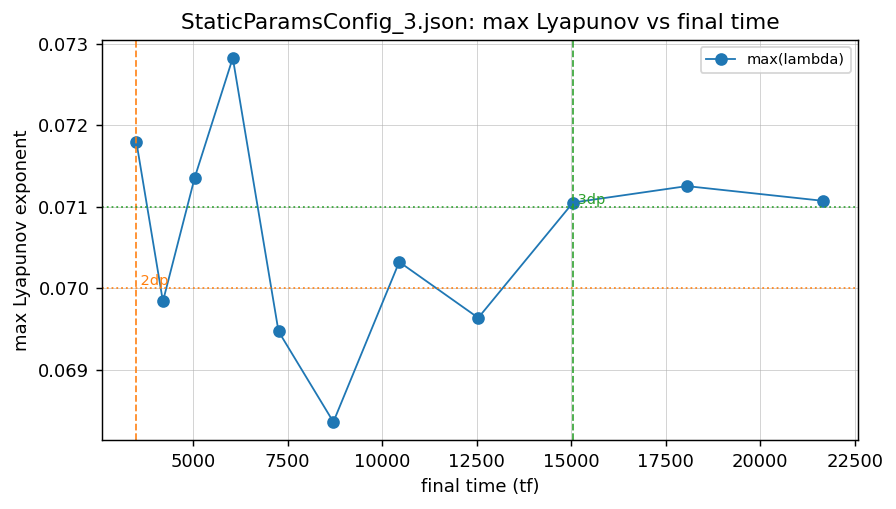


=== StaticParamsConfig_4.json (custom) ===
stop condition: reached tf cap = 200000
decimals=2: plateau at tf=10000.000 (steps=1000000), rounded max(lambda)=0.02
decimals=3: no plateau found


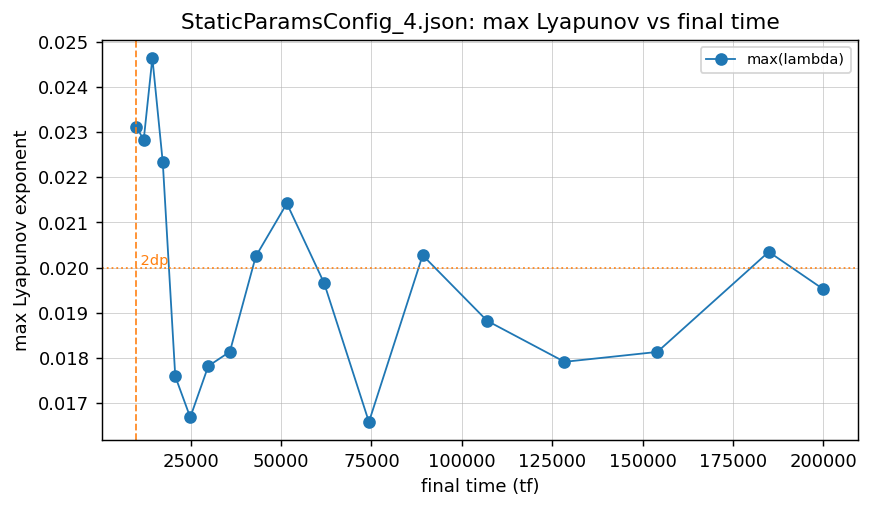


=== StaticParamsConfig_5.json (custom) ===
stop condition: reached tf cap = 200000
decimals=2: plateau at tf=10000.000 (steps=1000000), rounded max(lambda)=0.22
decimals=3: no plateau found


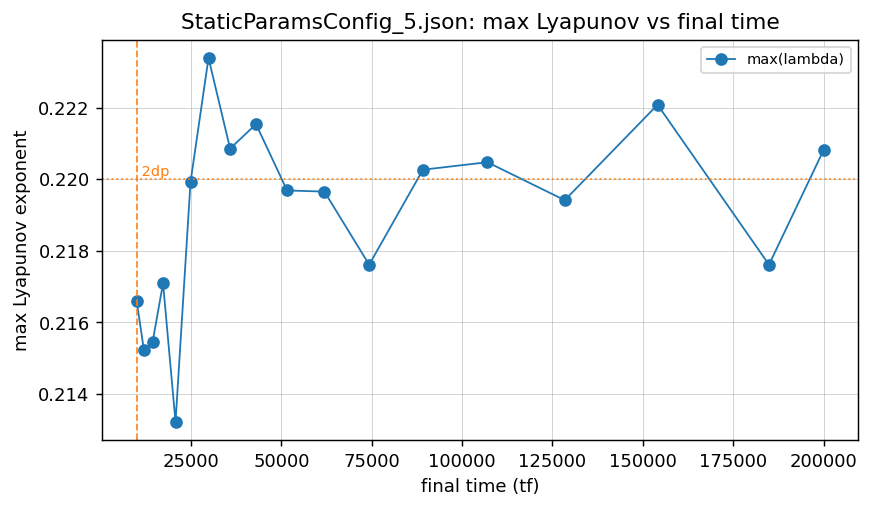


=== StaticParamsConfig_6.json (custom) ===
stop condition: 3dp plateau at tf=2500.000, rounded max(lambda)=0.000
decimals=2: plateau at tf=2500.000 (steps=250000), rounded max(lambda)=0.00
decimals=3: plateau at tf=2500.000 (steps=250000), rounded max(lambda)=0.000


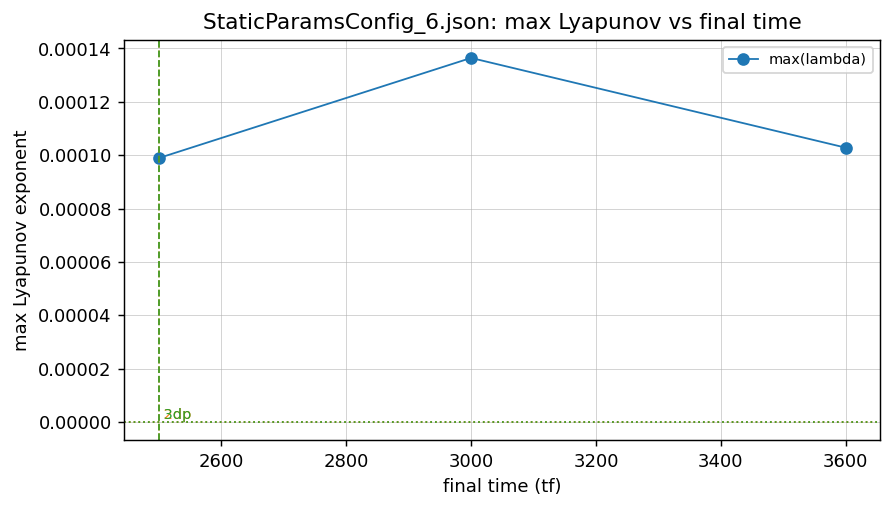


=== StaticParamsConfig_7.json (custom) ===
stop condition: 3dp plateau at tf=165618.430, rounded max(lambda)=0.267
decimals=2: plateau at tf=10749.540 (steps=1074954), rounded max(lambda)=0.27
decimals=3: plateau at tf=165618.430 (steps=16561843), rounded max(lambda)=0.267


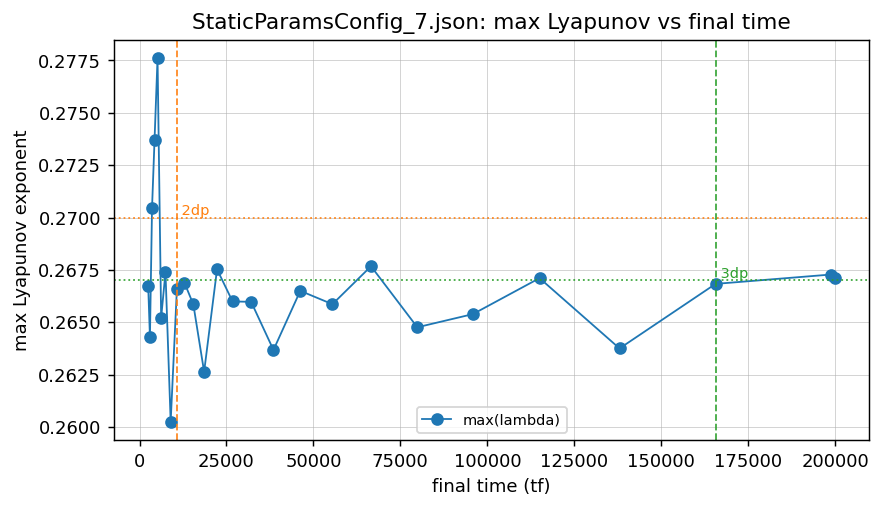


=== StaticParamsConfig_8.json (custom) ===
stop condition: 3dp plateau at tf=165618.430, rounded max(lambda)=0.023
decimals=2: plateau at tf=3000.000 (steps=300000), rounded max(lambda)=0.02
decimals=3: plateau at tf=165618.430 (steps=16561843), rounded max(lambda)=0.023


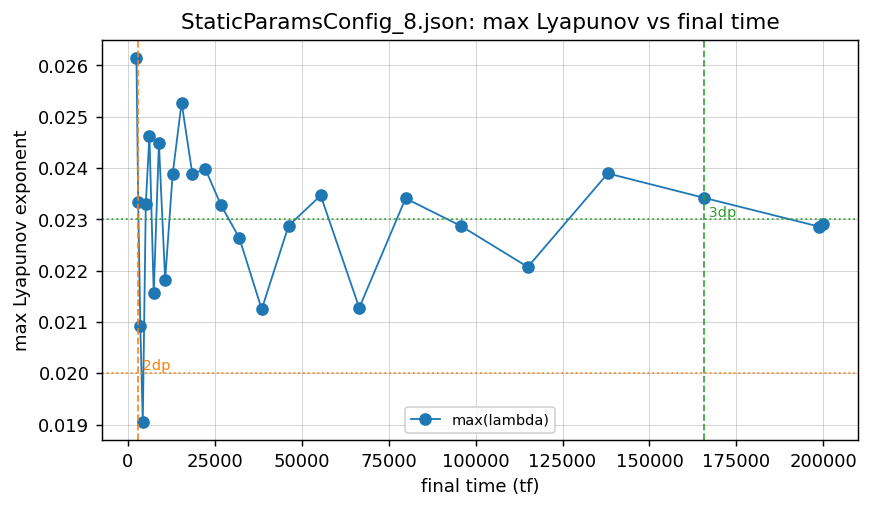


=== StaticParamsConfig_13.json (custom) ===
stop condition: 3dp plateau at tf=159740.000, rounded max(lambda)=0.271
decimals=2: plateau at tf=6000.000 (steps=600000), rounded max(lambda)=0.26
decimals=3: plateau at tf=159740.000 (steps=15974000), rounded max(lambda)=0.271


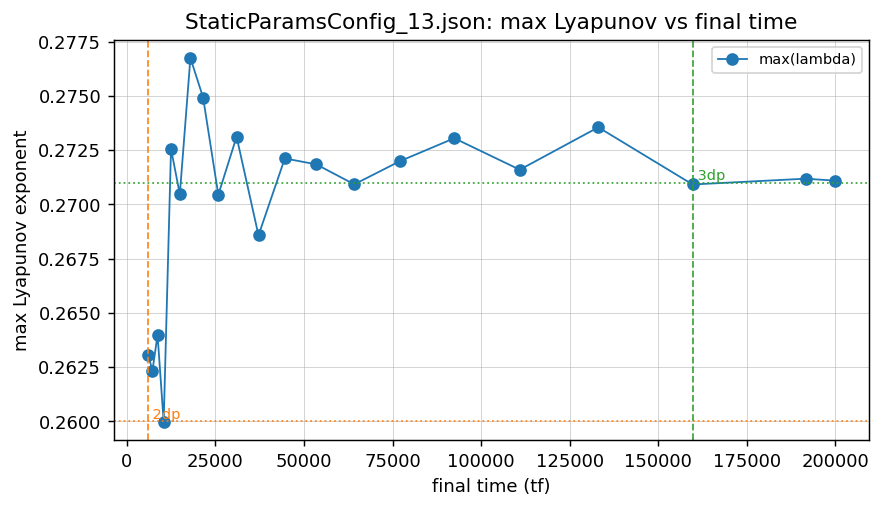


Summary:
StaticParamsConfig_3.json | custom | 2dp | tf=3500.000 | steps=350000 | rounded=0.07
StaticParamsConfig_3.json | custom | 3dp | tf=15049.360 | steps=1504936 | rounded=0.071
StaticParamsConfig_4.json | custom | 2dp | tf=10000.000 | steps=1000000 | rounded=0.02
StaticParamsConfig_4.json | custom | 3dp | no plateau
StaticParamsConfig_5.json | custom | 2dp | tf=10000.000 | steps=1000000 | rounded=0.22
StaticParamsConfig_5.json | custom | 3dp | no plateau
StaticParamsConfig_6.json | custom | 2dp | tf=2500.000 | steps=250000 | rounded=0.00
StaticParamsConfig_6.json | custom | 3dp | tf=2500.000 | steps=250000 | rounded=0.000
StaticParamsConfig_7.json | custom | 2dp | tf=10749.540 | steps=1074954 | rounded=0.27
StaticParamsConfig_7.json | custom | 3dp | tf=165618.430 | steps=16561843 | rounded=0.267
StaticParamsConfig_8.json | custom | 2dp | tf=3000.000 | steps=300000 | rounded=0.02
StaticParamsConfig_8.json | custom | 3dp | tf=165618.430 | steps=16561843 | rounded=0.023
StaticParams

In [13]:
if not numba_backend.numba_available():
    raise RuntimeError("Numba backend is not available. Install numba to run plateau tests.")

from app import numba_custom

import re
from pathlib import Path
from typing import Any

PROJECT_ROOT_LOCAL = PROJECT_ROOT
if PROJECT_ROOT_LOCAL is None:
    raise RuntimeError("PROJECT_ROOT is not initialized.")
TESTS_DIR = PROJECT_ROOT_LOCAL / "tests"

TF_MAX = 200000.0
LYAP_DT_OVERRIDE = 0.01
TF_GROWTH = 1.20
MIN_STABLE_RUN = 3
DECIMAL_TARGETS = (2, 3)
PLATEAU_STOP_DECIMALS = 3
PLOT_PER_CONFIG = True


def _as_float(value: Any, default: float) -> float:
    if value is None:
        return float(default)
    try:
        return float(value)
    except (TypeError, ValueError):
        return float(default)


def _as_int(value: Any, default: int) -> int:
    if value is None:
        return int(default)
    try:
        return int(value)
    except (TypeError, ValueError):
        return int(default)


def _cfg_sort_key(path: Path) -> int:
    m = re.search(r"_(\d+)\.json$", path.name)
    return int(m.group(1)) if m else 10**9


CONFIG_CANDIDATES = sorted(
    TESTS_DIR.glob("StaticParamsConfig_*.json"),
    key=_cfg_sort_key,
)


def load_json_config(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def resolve_system_params(sys_cfg: dict) -> dict[str, float]:
    params = {}
    params_raw = sys_cfg.get("params") or {}
    if isinstance(params_raw, dict):
        for k, v in params_raw.items():
            params[str(k)] = _as_float(v, 0.0)

    if not params and sys_cfg.get("params_text"):
        params = parse_params_text(str(sys_cfg.get("params_text")))

    return {str(k): _as_float(v, 0.0) for k, v in params.items()}


def build_numba_rhs_and_params_from_config(cfg: dict):
    sys_cfg = cfg.get("system") or {}
    key = str(sys_cfg.get("system_key", "")).lower().strip()
    params = resolve_system_params(sys_cfg)

    if key in ("lorenz", "rossler", "henon_heiles"):
        rhs_nb, jac_nb, param_names = numba_backend.build_builtin_system(key)
        values = []
        for name in param_names:
            if name in params:
                values.append(_as_float(params[name], 0.0))
            elif name == "lambda" and "lam" in params:
                values.append(_as_float(params["lam"], 0.0))
            else:
                raise ValueError(f"Missing parameter {name!r} for system {key!r}.")
        params_arr = np.asarray(values, dtype=float)
        return rhs_nb, jac_nb, False, params_arr, key

    if key == "custom":
        var_names = [str(v) for v in (sys_cfg.get("var_names") or [])]
        eq_lines = [str(v) for v in (sys_cfg.get("eq_lines") or [])]
        if len(var_names) == 0 or len(eq_lines) == 0:
            raise ValueError("Custom system requires var_names and eq_lines.")
        if len(var_names) != len(eq_lines):
            raise ValueError("Custom system: eq_lines must match var_names length.")

        param_names = list(params.keys())
        if len(param_names) == 0:
            raise ValueError("Custom system requires parameters for Numba compilation.")

        auto_jac = bool(sys_cfg.get("auto_jacobian", False))
        use_jac = bool(sys_cfg.get("use_jacobian", False))

        if auto_jac and use_jac:
            rhs_nb, jac_nb = numba_custom.build_custom_numba_rhs_and_jacobian(
                var_names,
                eq_lines,
                param_names,
            )
            use_fd_jac = False
        else:
            rhs_nb = numba_custom.build_custom_numba_rhs(var_names, eq_lines, param_names)
            jac_nb = None
            use_fd_jac = True

        params_arr = np.asarray([_as_float(params[name], 0.0) for name in param_names], dtype=float)
        return rhs_nb, jac_nb, use_fd_jac, params_arr, key

    raise ValueError(f"Unsupported system_key: {key!r}")


def resolve_lyapunov_runtime(cfg: dict):
    integ = cfg.get("integration") or {}
    lyap_cfg = cfg.get("lyapunov") or {}
    settings = lyap_cfg.get("settings") or {}

    t0 = _as_float(integ.get("t0"), 0.0)
    base_tf = _as_float(integ.get("tf"), 1.0)
    lyap_dt = float(LYAP_DT_OVERRIDE)

    y0_raw = integ.get("y0") or []
    y0 = np.asarray(y0_raw, dtype=float)
    if y0.size == 0:
        raise ValueError("Config integration.y0 is empty.")

    qr_every_steps = _as_int(settings.get("qr_every_steps"), 0)
    qr_interval = _as_float(settings.get("qr_interval"), 0.0)
    if qr_interval > 0.0:
        qr_every_steps = max(1, int(round(qr_interval / lyap_dt)))
    elif qr_every_steps <= 0:
        qr_every_steps = max(1, int(round(0.1 / lyap_dt)))

    fd_eps = _as_float(settings.get("fd_eps"), 1e-8)

    total_base = max(base_tf - t0, lyap_dt)
    transient_fraction_raw = settings.get("transient_fraction")
    transient_steps_raw = settings.get("transient_steps")
    t_transient_raw = settings.get("t_transient")
    t_measure_raw = settings.get("t_measure")

    if transient_fraction_raw is not None:
        transient_fraction = _as_float(transient_fraction_raw, 0.3)
    elif transient_steps_raw is not None:
        transient_fraction = _as_float(transient_steps_raw, 0.0) * lyap_dt / total_base
    elif t_transient_raw is not None and t_measure_raw is not None:
        t_trans = _as_float(t_transient_raw, 0.0)
        t_meas = _as_float(t_measure_raw, 0.0)
        denom = t_trans + t_meas
        transient_fraction = (t_trans / denom) if denom > 0.0 else 0.3
    elif t_transient_raw is not None:
        transient_fraction = _as_float(t_transient_raw, 0.0) / total_base
    else:
        transient_fraction = 0.3

    transient_fraction = min(max(float(transient_fraction), 0.0), 0.99)
    return t0, base_tf, lyap_dt, y0, qr_every_steps, fd_eps, transient_fraction


def build_tf_grid(t0: float, base_tf: float, lyap_dt: float, tf_max: float) -> np.ndarray:
    tf_upper = max(_as_float(tf_max, base_tf), t0 + 100.0 * lyap_dt)
    start_raw = min(max(base_tf, t0 + 100.0 * lyap_dt), tf_upper)

    vals = [start_raw]
    curr = start_raw
    guard = 0
    while curr < tf_upper - 1e-12 and guard < 512:
        curr = min(tf_upper, curr * float(TF_GROWTH))
        vals.append(curr)
        guard += 1

    snapped = []
    for tf_raw in vals:
        n_steps = max(1, int(round((float(tf_raw) - t0) / lyap_dt)))
        tf_snap = t0 + n_steps * lyap_dt
        tf_snap = min(tf_snap, tf_upper)
        snapped.append(float(tf_snap))

    return np.asarray(sorted(set(snapped)), dtype=float)


def find_plateau_index_by_rounding(values: np.ndarray, decimals: int, min_run: int):
    if values.size < min_run:
        return None
    rounded = np.round(values, int(decimals))
    run_len = 1
    for i in range(1, rounded.size):
        if rounded[i] == rounded[i - 1]:
            run_len += 1
            if run_len >= int(min_run):
                start_idx = i - run_len + 1
                return start_idx, float(rounded[i])
        else:
            run_len = 1
    return None


def compute_lmax_series_numba(cfg_path: Path):
    cfg = load_json_config(cfg_path)
    rhs_nb, jac_nb, use_fd_jac, params_arr, system_key_local = build_numba_rhs_and_params_from_config(cfg)
    lyap_nb = numba_backend.build_lyapunov_solver(rhs_nb, jac_nb, use_fd_jac=use_fd_jac)

    t0, base_tf, lyap_dt, y0, qr_every_steps, fd_eps, transient_fraction = resolve_lyapunov_runtime(cfg)
    tf_grid = build_tf_grid(t0, base_tf, lyap_dt, TF_MAX)

    tf_vals = []
    lmax_vals = []
    stop_plateau_3dp = None

    for tf_curr in tf_grid:
        total_time = float(tf_curr) - float(t0)
        if total_time <= 0.0:
            continue

        t_transient = transient_fraction * total_time
        t_measure = total_time - t_transient
        if t_measure <= 0.0:
            continue

        lambdas, _sums, _t_meas, n_qr, _x_final = lyap_nb(
            np.asarray(y0, dtype=float),
            float(t0),
            float(lyap_dt),
            float(t_transient),
            float(t_measure),
            int(qr_every_steps),
            float(fd_eps),
            np.asarray(params_arr, dtype=float),
        )
        if int(n_qr) <= 0:
            continue

        lambdas = np.asarray(lambdas, dtype=float)
        tf_vals.append(float(tf_curr))
        lmax_vals.append(float(np.max(lambdas)))

        plateau_3dp = find_plateau_index_by_rounding(
            values=np.asarray(lmax_vals, dtype=float),
            decimals=int(PLATEAU_STOP_DECIMALS),
            min_run=int(MIN_STABLE_RUN),
        )
        if plateau_3dp is not None:
            stop_plateau_3dp = plateau_3dp
            break

    return {
        "cfg": cfg,
        "system_key": system_key_local,
        "t0": float(t0),
        "lyap_dt": float(lyap_dt),
        "tf_vals": np.asarray(tf_vals, dtype=float),
        "lmax_vals": np.asarray(lmax_vals, dtype=float),
        "stop_plateau_3dp": stop_plateau_3dp,
    }


existing_paths = [p for p in CONFIG_CANDIDATES if p.exists()]
existing_paths = [p for p in existing_paths if re.search(r"_(\d+)\.json$", p.name)]
if not existing_paths:
    raise FileNotFoundError("No config files found in CONFIG_CANDIDATES.")

summary_rows = []

for cfg_path in existing_paths:
    out = compute_lmax_series_numba(cfg_path)
    tf_vals = out["tf_vals"]
    lmax_vals = out["lmax_vals"]
    t0_local = out["t0"]
    lyap_dt_local = out["lyap_dt"]

    print()
    print(f"=== {cfg_path.name} ({out['system_key']}) ===")

    if tf_vals.size == 0:
        print("No valid Lyapunov points.")
        for decimals in DECIMAL_TARGETS:
            summary_rows.append(
                {
                    "config": cfg_path.name,
                    "system": out["system_key"],
                    "decimals": int(decimals),
                    "plateau_found": False,
                    "plateau_tf": np.nan,
                    "plateau_steps": np.nan,
                    "rounded_value": np.nan,
                }
            )
        continue

    stop_plateau_3dp = out.get("stop_plateau_3dp")
    if stop_plateau_3dp is not None:
        stop_idx, stop_val = stop_plateau_3dp
        print(
            f"stop condition: 3dp plateau at tf={float(tf_vals[stop_idx]):.3f}, "
            f"rounded max(lambda)={float(stop_val):.3f}"
        )
    elif float(tf_vals[-1]) >= float(TF_MAX) - 1e-9:
        print(f"stop condition: reached tf cap = {TF_MAX:g}")

    for decimals in DECIMAL_TARGETS:
        plateau = find_plateau_index_by_rounding(
            values=lmax_vals,
            decimals=int(decimals),
            min_run=int(MIN_STABLE_RUN),
        )
        if plateau is None:
            print(f"decimals={decimals}: no plateau found")
            summary_rows.append(
                {
                    "config": cfg_path.name,
                    "system": out["system_key"],
                    "decimals": int(decimals),
                    "plateau_found": False,
                    "plateau_tf": np.nan,
                    "plateau_steps": np.nan,
                    "rounded_value": np.nan,
                }
            )
            continue

        idx, rounded_val = plateau
        tf_plateau = float(tf_vals[idx])
        steps_plateau = int(round((tf_plateau - t0_local) / lyap_dt_local))
        print(
            f"decimals={decimals}: plateau at tf={tf_plateau:.3f} "
            f"(steps={steps_plateau}), rounded max(lambda)={rounded_val:.{int(decimals)}f}"
        )

        summary_rows.append(
            {
                "config": cfg_path.name,
                "system": out["system_key"],
                "decimals": int(decimals),
                "plateau_found": True,
                "plateau_tf": tf_plateau,
                "plateau_steps": steps_plateau,
                "rounded_value": rounded_val,
            }
        )

    if PLOT_PER_CONFIG:
        fig, ax = plt.subplots(figsize=(7.5, 4.0))
        fig.set_dpi(130)
        ax.plot(tf_vals, lmax_vals, marker="o", linewidth=1.0, label="max(lambda)")

        for decimals, color in zip(DECIMAL_TARGETS, ["tab:orange", "tab:green"]):
            plateau = find_plateau_index_by_rounding(lmax_vals, int(decimals), int(MIN_STABLE_RUN))
            if plateau is None:
                continue
            idx, rounded_val = plateau
            ax.axvline(tf_vals[idx], color=color, linestyle="--", linewidth=1.0, alpha=0.9)
            ax.axhline(rounded_val, color=color, linestyle=":", linewidth=1.0, alpha=0.9)
            ax.text(
                tf_vals[idx],
                rounded_val,
                f" {decimals}dp",
                color=color,
                fontsize=8,
                va="bottom",
            )

        ax.set_title(f"{cfg_path.name}: max Lyapunov vs final time")
        ax.set_xlabel("final time (tf)")
        ax.set_ylabel("max Lyapunov exponent")
        ax.grid(True, linewidth=0.3)
        ax.legend(loc="best", fontsize=8)
        plt.show()

print()
print("Summary:")
for row in summary_rows:
    if row["plateau_found"]:
        print(
            f"{row['config']} | {row['system']} | {row['decimals']}dp | "
            f"tf={row['plateau_tf']:.3f} | steps={int(row['plateau_steps'])} | "
            f"rounded={row['rounded_value']:.{int(row['decimals'])}f}"
        )
    else:
        print(f"{row['config']} | {row['system']} | {row['decimals']}dp | no plateau")



## 7) Tolerances vs Lyapunov max value

We sweep absolute tolerance and set relative tolerance so that:
`rtol * y_scale == atol`, where `y_scale = max(|Y|)`.


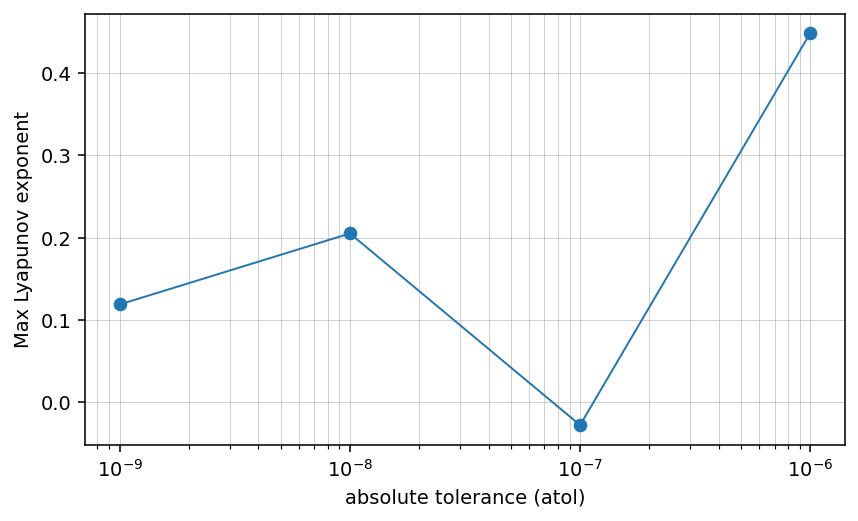

atol=1.0e-06 rtol=1.849e-07 max_lambda=0.448778
atol=1.0e-07 rtol=1.849e-08 max_lambda=-0.027994
atol=1.0e-08 rtol=1.849e-09 max_lambda=0.205121
atol=1.0e-09 rtol=1.849e-10 max_lambda=0.118766


In [14]:
if not bool(lyap_cfg.get("enabled", True)):
    print("Lyapunov disabled in config.")
else:
    atols = [1e-6, 1e-7, 1e-8, 1e-9]
    y_scale = float(np.max(np.abs(Y)))
    y_scale = max(y_scale, 1.0)

    max_vals = []
    rtols = []

    for atol in atols:
        rtol = float(atol) / y_scale
        rtols.append(rtol)
        opts = dict(lyap_solve_opts)
        opts.update({"rtol": float(rtol), "atol": float(atol)})

        res = compute_lyapunov_spectrum(
            rhs=rhs,
            x0=np.asarray(y0, dtype=float),
            t0=float(t0),
            dt=float(lyap_dt),
            t_transient=float(t_transient),
            t_measure=float(t_measure),
            qr_every_steps=int(qr_every_steps),
            jac=jac_to_use,
            fd_eps=float(fd_eps),
            solver_kind=lyap_solver_kind,
            auto_switch_rk4=auto_switch_rk4,
            solve_options=opts,
        )
        max_vals.append(float(np.max(res.lambdas)))

    fig, ax = plt.subplots(figsize=(7.0, 4.0))
    fig.set_dpi(140)
    ax.semilogx(atols, max_vals, marker="o", linewidth=1.0)
    ax.set_xlabel("absolute tolerance (atol)")
    ax.set_ylabel("Max Lyapunov exponent")
    ax.grid(True, linewidth=0.3, which="both")
    plt.show()

    for atol, rtol, val in zip(atols, rtols, max_vals):
        print(f"atol={atol:.1e} rtol={rtol:.3e} max_lambda={val:.6f}")
